In [1]:
import sys
sys.path.append('../')
from source import Node 
from source import Align
import glob
from pathlib import Path
import networkx as nx
from ipysigma import Sigma
import pandas as pd
import math
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

/home/tiago/anaconda3/envs/databases/lib/python3.10/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


In [2]:
# Node.PrepareGenomeQueryFasta(
#     genomes_dir="../data/genomes"
# )

In [3]:
FastaFiles = glob.glob("../data/processed/selected_components/*.fasta")
FastaFiles

['../data/processed/selected_components/ProblematicComponentsByClass.aminocoumarin.fasta',
 '../data/processed/selected_components/ProblematicComponentsByClass.aminoglycoside.fasta',
 '../data/processed/selected_components/ProblematicComponentsByClass.bacitracin.fasta',
 '../data/processed/selected_components/ProblematicComponentsByClass.beta-lactam.fasta',
 '../data/processed/selected_components/ProblematicComponentsByClass.colistin.fasta',
 '../data/processed/selected_components/ProblematicComponentsByClass.drug_and_biocide_and_metal_resistance.fasta',
 '../data/processed/selected_components/ProblematicComponentsByClass.drug_and_biocide_resistance.fasta',
 '../data/processed/selected_components/ProblematicComponentsByClass.elfamycin.fasta',
 '../data/processed/selected_components/ProblematicComponentsByClass.fluoroquinolone.fasta',
 '../data/processed/selected_components/ProblematicComponentsByClass.fosfomycin.fasta',
 '../data/processed/selected_components/ProblematicComponentsByCla

In [4]:
for file in FastaFiles:
    name = file.split("/")[-1].split(".")[-2]
    if not Path(f"../data/processed/diamond_db/{name}.dmnd").is_file():
        Node.MakeDiamondDB(
        fasta_dir=file,
        db_dir="../data/processed/diamond_db/",
        db_name = name)
    print("All databases are already created")

All databases are already created
All databases are already created
All databases are already created
All databases are already created
All databases are already created
All databases are already created
All databases are already created
All databases are already created
All databases are already created
All databases are already created
All databases are already created
All databases are already created
All databases are already created
All databases are already created
All databases are already created
All databases are already created
All databases are already created
All databases are already created
All databases are already created


In [5]:
DiamondDatabase = glob.glob("../data/processed/diamond_db/*.dmnd")
DiamondDatabase

['../data/processed/diamond_db/aminocoumarin.dmnd',
 '../data/processed/diamond_db/aminoglycoside.dmnd',
 '../data/processed/diamond_db/bacitracin.dmnd',
 '../data/processed/diamond_db/beta-lactam.dmnd',
 '../data/processed/diamond_db/colistin.dmnd',
 '../data/processed/diamond_db/drug_and_biocide_and_metal_resistance.dmnd',
 '../data/processed/diamond_db/drug_and_biocide_resistance.dmnd',
 '../data/processed/diamond_db/elfamycin.dmnd',
 '../data/processed/diamond_db/fluoroquinolone.dmnd',
 '../data/processed/diamond_db/fosfomycin.dmnd',
 '../data/processed/diamond_db/fosmidomycin.dmnd',
 '../data/processed/diamond_db/glycopeptide.dmnd',
 '../data/processed/diamond_db/macrolide.dmnd',
 '../data/processed/diamond_db/multidrug.dmnd',
 '../data/processed/diamond_db/phosphonic_acid.dmnd',
 '../data/processed/diamond_db/polymyxin.dmnd',
 '../data/processed/diamond_db/quinolone.dmnd',
 '../data/processed/diamond_db/rifampin.dmnd',
 '../data/processed/diamond_db/tetracycline.dmnd']

In [6]:
for database in DiamondDatabase:
    name = database.split("/")[-1].split(".")[0]
    name = name.replace(" ","_")
    if not Path(f"../data/processed/diamond_results/NodeProteinAlignment.{name}.tsv").is_file():
        Align.RunDiamond(
            query="../data/genomes/all_genomes_query.fasta",
            db=database,
            output=f"../data/processed/diamond_results/NodeProteinAlignment.{name}.tsv",
            maxseq=6,
            qcov = 80,
            minid = 90
            )
    else:
        print("All alignments done!")

All alignments done!
All alignments done!
All alignments done!
All alignments done!
All alignments done!
All alignments done!
All alignments done!
All alignments done!
All alignments done!
All alignments done!
All alignments done!
All alignments done!
All alignments done!
All alignments done!
All alignments done!
All alignments done!
All alignments done!
All alignments done!
All alignments done!


In [333]:
color_map = {
    'multidrug':      "#FD6F63",
    'efflux':         "#FEB1B1",     
    'beta-lactam':    "#89BDE7",  
    'bacitracin':     "#2E8D19",    
    'tetracycline':   "#CD73E8",
    'glycopeptide':   "#F3BC71",  
    'peptide':        "#EAFF00",  
    'macrolide':      "#D4D451",
    'triclosan':      "#09FF00",
    'MLS':            "#FF0000",
    'ml':              "#A12525",
    'aminoglycoside': "#ECAD2F", 
    'quinolone':      "#14E974",
    'drug_and_biocide_resistance': "#EA17B9",
    "drug_and_biocide_and_metal_resistance": "#EA17B9",
    'fosfomycin':     "#6063F4",
    'fluoroquinolone':"#60D4F4",
    'elfamycin':      "#7B079E",
    'aminocoumarin':  "#EE00F6",
    'rifampin':       "#0BF8E8",
    'phosphonic acid':"#262897",
    'fosmidomycin':   "#7B5404",
    'colistin' :      "#7FBE03",
    'polymyxin':      "#97B262",
    'GenomeProtein':"#534F51",
    }

In [334]:
TargetClass = "bacitracin"
ProblematicComponentsByClass = nx.read_graphml(f"../data/processed/ProblematicComponentsByClass.{TargetClass}.graphml")

In [335]:
GenomeNodesAligned = pd.read_csv(
    f"../data/processed/diamond_results/NodeProteinAlignment.{TargetClass}.tsv", 
    sep = "\t",
    skipinitialspace=True, 
    header=None,
    names = "qseqid sseqid stitle pident length qlen slen qstart qend sstart send evalue bitscore ppos full_qseq full_sseq".split(" ")
)
GenomeNodesAligned["sseqid"] = GenomeNodesAligned.sseqid.apply(lambda x: x.split("|")[0])

In [336]:
ProblematicComponentsByClass_AndGenomes = nx.Graph(ProblematicComponentsByClass)
GenomeNodesDict = {}
NewNodes = []
for _,i in GenomeNodesAligned.iterrows():
    ProblematicComponentsByClass_AndGenomes.add_edge(i["sseqid"],i["qseqid"], pident = i["pident"])
    GenomeNodesDict[i["qseqid"]] = {"Drug Class":"GenomeProtein", "Sequence":i["full_qseq"], "Name":i["qseqid"].split("|")[-1]}
nx.set_node_attributes(ProblematicComponentsByClass_AndGenomes, GenomeNodesDict)

In [337]:
meu_layout = {
    "scalingRatio": 50.0,           # Aumente para afastar os grupos
    "gravity": 0.4,                 # Reduza para não amontoar no centro
    "repulsion": 2,               # Aumente para afastar os nós
    # "outboundAttractionDistribution": True, # Empurra hubs para fora
    # "barnesHutOptimize": True,      # Essencial para seus 70k nós
    # "linLogMode": True              # Melhora a definição de clusters biológicos 
}
Sigma(
    ProblematicComponentsByClass_AndGenomes, 
    node_size  = ProblematicComponentsByClass_AndGenomes.degree(),
    node_color =  [ProblematicComponentsByClass_AndGenomes.nodes[n].get("Drug Class") for n in ProblematicComponentsByClass_AndGenomes.nodes()],
    raw_node_color=True,
    node_color_palette = color_map,
    default_edge_type = "curve",
    layout_settings=meu_layout,
    start_layout=15,
    label_density = 0
    )

Sigma(nx.Graph with 3,085 nodes and 2,663 edges)

In [357]:
NodeBait = " NDARO_9470"

StringFasta = []
for component in list(nx.connected_components(ProblematicComponentsByClass_AndGenomes)):
    if NodeBait.strip() in component:
        for nodes in component:
            DrugClass = ProblematicComponentsByClass_AndGenomes.nodes[nodes]['Drug Class']
            Sequence = ProblematicComponentsByClass_AndGenomes.nodes[nodes]['Sequence']
            Name = ProblematicComponentsByClass_AndGenomes.nodes[nodes]['Name']
            StringFasta.append(f">{nodes}|{DrugClass}|{Name}\n{Sequence}")
AlignedComponent = Align.ProteinAligner(StringFasta)


AlignLenDist = []
with open(f"../data/processed/msa/{TargetClass}-{NodeBait}.fasta", "w+") as MSA_FILE:
    for AlignedSeq in AlignedComponent:
        MSA_FILE.write(f">{AlignedSeq.id}\n{AlignedSeq.seq}\n")
        AlignLenDist.append(len(AlignedSeq.seq.replace("-","")))
        print(f">{AlignedSeq.id}")
        print(AlignedSeq.seq)

>MEGARES_2128|aminocoumarin|gyrba
-VTALSDVNNTDNYGAGQIQVLEGLEAVRKRPGMYIGSTSERGLHHLVWEIVDNSIDEALAGYANQIEVVIEKDNWIKVTDNGRGIPVDIQEKMGRPAVEVILTVLHAGGKFGGGGYKVSGGLHGVGSSVVNALSQDLEVYVHRNETIYHQAYKKGVPQFDLKEVGTTDKTGTVIRFKADGEIFTETTVYNYETLQQRIRELAFLNKGIQITLRDERDEENVREDSYHYEGGIKSYVELLNENKEPIHDEPIYIHQSKDDIEVEIAIQYNSGYATNLLTYANNIHTYEGGTHEDGFKRALTRVLNSYGLSSKIMKEDKDRLSGEDTREGMTAIISIKHGDPQFEGQTKTKLGNSEVRQVVDKLFSEHFERFLYENPQVARTVVEKGIMAARARVAAKKAREVTRRKSALDVASLPGKLADCSSKSPEECEIFLVEGDSAGGSTKSGRDSRTQAILPLRGKILNVEKARLDRILNNNEIRQMITAFGTGIGGDFDLAKARYHKIVIMTDADVDGAHIRTLLLTFFYRFMRPLIEAGYVYIAQPPLYKLTQGKQKYYVYNDRELDKLKSELNPTPKWSIARYKGLGEMNADQLWETTMNPEHRALLQVKLEDAIEADQTFEMLMGDVVENRRQFIEDNAVYANLDF
>HMD_15438|aminocoumarin|gyrb
MVTALSDVNNTDNYGAGQIQVLEGLEAVRKRPGMYIGSTSERGLHHLVWEIVDNSIDEALAGYANQIEVVIEKDNWIKVTDNGRGIPVDIQEKMGRPAVEVILTVLHAGGKFGGGGYKVSGGLHGVGSSVVNALSQDLEVYVHRNETIYHQAYKKGVPQFDLKEVGTTDKTGTVIRFKADGEIFTETTVYNYETLQQRIRELAFLNKGIQITLRDERDEENVREDSYHYEGGIKSYVELLNENKEPIHDEPIYIHQSKDDIEVEIAIQYNSGYATNLLTYANNIHTYEGGT

In [358]:
def ShannonEntropy(Column, IgnorGap = True):
    if IgnorGap:
        Column = [residue for residue in Column if residue != "-"]
    TotalResidues = len(Column)
    if TotalResidues == 0:
        return 0
    Count = Counter(Column)
    Entropy = 0
    for value in Count.values():
        p = value/TotalResidues
        Entropy -= p*math.log2(p)
    return Entropy

In [359]:
AlignLen = AlignedComponent.get_alignment_length()
EntropyForPosition = []

In [360]:
for i in range(0,AlignLen):
    Col = AlignedComponent[:,i]
    h  =  ShannonEntropy(Col, IgnorGap=False)
    EntropyForPosition.append({
        "Position": i+1,
        "Entropy":round(h,3)
    })
EntropyFrame = pd.DataFrame(EntropyForPosition)

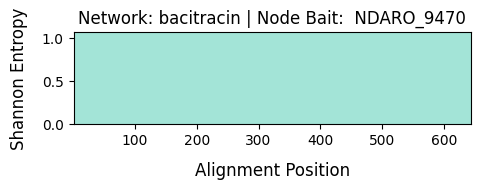

In [361]:
fig, ax = plt.subplots(figsize=(5,2))
ax.set_facecolor('#A3E4D7')
ax.bar(
    EntropyFrame['Position'],
    EntropyFrame['Entropy'],
    width = 2,
    color = '#555555'
)
ax.set_xlim(EntropyFrame["Position"].min(), EntropyFrame["Position"].max())
ax.set_ylim(0, EntropyFrame["Entropy"].max() * 1.1)
ax.set_xlabel("Alignment Position", fontsize = 12, labelpad=10)
ax.set_ylabel("Shannon Entropy",fontsize = 12, labelpad=10)
ax.set_title(f"Network: {TargetClass} | Node Bait: {NodeBait}")

plt.tight_layout() 
plt.savefig(f"../figures/ShannonEntropy.{TargetClass}.{NodeBait}.svg", 
            format="svg", 
            dpi=180, 
            bbox_inches='tight')

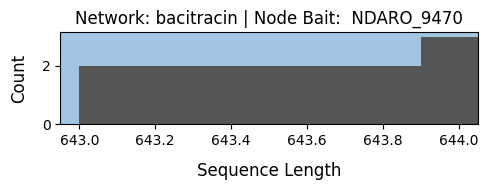

In [362]:
fig, ax = plt.subplots(figsize=(5,2))
ax.set_facecolor("#A3C5E4")
ax.hist(
    AlignLenDist,
    width = 10,
    color = "#555555"
)
ax.set_xlabel("Sequence Length", fontsize = 12, labelpad=10)
ax.set_ylabel("Count", fontsize = 12, labelpad=10)
ax.set_title(f"Network: {TargetClass} | Node Bait: {NodeBait}")

plt.tight_layout() 
plt.savefig(f"../figures/ComponentLenDist.{TargetClass}.{NodeBait}.svg", 
            format="svg", 
            dpi=180, 
            bbox_inches='tight')